In [45]:
import pandas as pd
import numpy as np
import sklearn.tree 
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeClassifier, RidgeCV, LassoCV, Lasso, LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

In [46]:
def PolyFeatures(X,degree=2,interaction_only=False):
    poly = PolynomialFeatures(degree,interaction_only=interaction_only)
    if X.ndim == 1:
        Xe = poly.fit_transform(X.values.reshape(-1,1))
        cols = poly.get_feature_names_out([X.name])
    else:
        Xe = poly.fit_transform(X)
        cols = poly.get_feature_names_out(X.columns)
    Xe = pd.DataFrame(Xe,columns=cols)
    print('X shape =',X.shape)
    print('X (engineered) shape =',Xe.shape)
    return Xe

In [47]:
df = pd.read_csv("dataset1.csv")
print(df.shape)
print(df.info())
df.head(5)

(11055, 32)
<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   index                         11055 non-null  int64
 1   having_IPhaving_IP_Address    11055 non-null  int64
 2   URLURL_Length                 11055 non-null  int64
 3   Shortining_Service            11055 non-null  int64
 4   having_At_Symbol              11055 non-null  int64
 5   double_slash_redirecting      11055 non-null  int64
 6   Prefix_Suffix                 11055 non-null  int64
 7   having_Sub_Domain             11055 non-null  int64
 8   SSLfinal_State                11055 non-null  int64
 9   Domain_registeration_length   11055 non-null  int64
 10  Favicon                       11055 non-null  int64
 11  port                          11055 non-null  int64
 12  HTTPS_token                   11055 non-null  int64
 13  Request_URL                   

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [48]:
X = df.drop(columns=["Result"])
y = df["Result"]

stnd = StandardScaler().set_output(transform='pandas')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

X_train = stnd.fit_transform(X_train)
X_test = stnd.transform(X_test)

ridge = RidgeClassifier(random_state=0)
ridge.fit(X_train, y_train)

accuracy = ridge.score(X_test, y_test)
error_rate = 1 - accuracy
print(accuracy, error_rate)

0.9253731343283582 0.07462686567164178


In [49]:
from sklearn.metrics import confusion_matrix

y_pred = ridge.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 878,  102],
       [  63, 1168]])

In [50]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

          -1       0.93      0.90      0.91       980
           1       0.92      0.95      0.93      1231

    accuracy                           0.93      2211
   macro avg       0.93      0.92      0.92      2211
weighted avg       0.93      0.93      0.93      2211



In [51]:
grid = {'alpha':[0.0001,0.001,0.01,0.1,1,10,100,1000,10000,100000]}

In [52]:
Xe_train = PolyFeatures(X_train, 2)
Xe_test = PolyFeatures(X_test, 2)

X shape = (8844, 31)
X (engineered) shape = (8844, 528)
X shape = (2211, 31)
X (engineered) shape = (2211, 528)


In [53]:
ridgeCV = GridSearchCV(RidgeClassifier(), grid, return_train_score=True)
lassoCV = GridSearchCV(Lasso(), grid, return_train_score=True)

ridgeCV.fit(Xe_train, y_train)
lassoCV.fit(Xe_train, y_train)

/home/kennym1/.conda/envs/MA384/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.819e+02, tolerance: 6.999e-01
  model = cd_fast.enet_coordinate_descent(
/home/kennym1/.conda/envs/MA384/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.291e+02, tolerance: 6.977e-01
  model = cd_fast.enet_coordinate_descent(
/home/kennym1/.conda/envs/MA384/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are

In [54]:
print(ridgeCV.best_score_, lassoCV.best_score_)

0.9486662582587497 0.8022205528845608


In [55]:
ridgeCV.best_estimator_.fit(Xe_train, y_train)

y_pred = ridgeCV.best_estimator_.predict(Xe_test)

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - error_rate

print("Tuned Ridge Classifier Results")
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print()

print("Confusion Matrix:")
M_pca_best = confusion_matrix(y_test, y_pred, labels=[-1, 1])
ConfusionMatrix_pca_best = pd.DataFrame(
    M_pca_best,
    index=["Legitimate (-1)", "Phishing (1)"],
    columns=["Legitimate (-1)", "Phishing (1)"]
)
ConfusionMatrix_pca_best["total"] = ConfusionMatrix_pca_best.sum(axis=1)
print(ConfusionMatrix_pca_best)
print()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[-1, 1],
    target_names=["Legitimate (-1)", "Phishing (1)"]
))

Tuned Ridge Classifier Results
Accuracy: 0.9507010402532791
Error Rate: 0.9253731343283582

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              905            75    980
Phishing (1)                  34          1197   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.96      0.92      0.94       980
   Phishing (1)       0.94      0.97      0.96      1231

       accuracy                           0.95      2211
      macro avg       0.95      0.95      0.95      2211
   weighted avg       0.95      0.95      0.95      2211



(-0.1, 0.1)

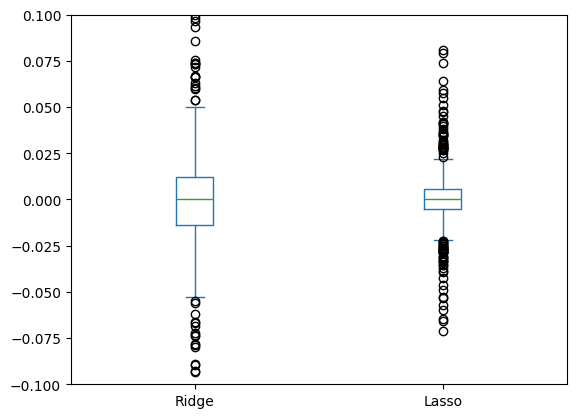

In [56]:
ridge = ridgeCV.best_estimator_
lasso = lassoCV.best_estimator_
coef = pd.DataFrame()
coef['Ridge'] = ridge.coef_
coef['Lasso'] = lasso.coef_
coef.plot.box()
plt.ylim(-0.1,0.1)

In [57]:
n_comp = Xe_train.shape[1]
# n_comp = 15
print('number of components',n_comp)

number of components 528


In [58]:
# create column names
cols = ['PC-'+str(i+1) for i in range(n_comp)]

PC-1      0.059999999999999997779553950750
PC-2      0.050000000000000002775557561563
PC-3      0.040000000000000000832667268469
PC-4      0.029999999999999998889776975375
PC-5      0.020000000000000000416333634234
                        ...               
PC-524    0.000000000000000000000000000000
PC-525    0.000000000000000000000000000000
PC-526    0.000000000000000000000000000000
PC-527    0.000000000000000000000000000000
PC-528    0.000000000000000000000000000000
Length: 528, dtype: float64


<Axes: title={'center': 'PVE'}>

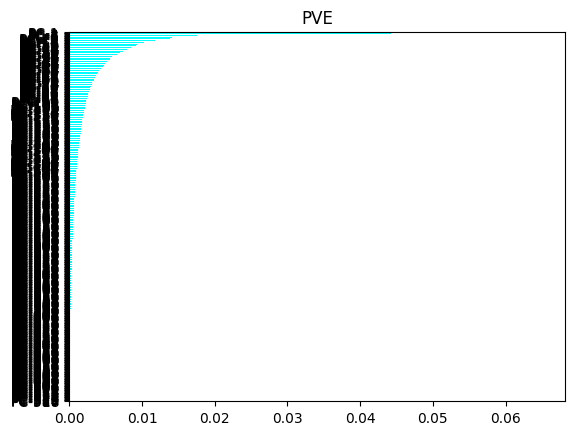

In [59]:
pca = PCA(n_components=n_comp)
pca.fit(stnd.fit_transform(Xe_train))
PVE = pca.explained_variance_ratio_
PVE = pd.Series(PVE,index=cols)
print(PVE.round(2))
PVE.sort_values().plot.barh(color='cyan',title='PVE')

In [60]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
PVE

PC-1      0.064968613192303181769204911689
PC-2      0.048806769848073250361863983926
PC-3      0.044283078453765056803348443282
PC-4      0.030111171639245058739842164641
PC-5      0.024383171446460349951479429365
PC-6      0.017611016849670022010876380136
PC-7      0.017289180175560737301454494741
PC-8      0.015366930574380993287930685653
PC-9      0.014127842323809485999830393155
PC-10     0.013862292221963392127581649049
PC-11     0.013185573515291435300889055782
PC-12     0.012794722123405134761586765535
PC-13     0.011711532696216849988579689068
PC-14     0.011227088247984805952084386149
PC-15     0.010824257327732539346598628072
PC-16     0.010280022398255287893742426775
PC-17     0.010045236899593783935769053528
PC-18     0.009696694095534696966609544688
PC-19     0.009310640612882377029069225216
PC-20     0.009174755882275472881892675048
PC-21     0.008838045832155977041266758931
PC-22     0.008757518324974648479819272495
PC-23     0.008442067720539472852614437670
PC-24     0

In [61]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [62]:
pca_results = []

component_options = [400, 450, 500, 510, 515, 520, 525, Xe_train.shape[1]]

for n in component_options:
    pca_temp = PCA(n_components=n)
    
    Xe_train_pca_temp = pca_temp.fit_transform(Xe_train)
    
    model_temp = RidgeClassifier(random_state=0)
    
    scores = cross_val_score(model_temp, Xe_train_pca_temp, y_train, cv=5, scoring="accuracy")
    
    pca_results.append({"num_components": n, "accuracy": scores.mean()})

pca_results = pd.DataFrame(pca_results)

print("PCA CV Results")
print(pca_results)
print("Best number of PCA components:", pca_results.iloc[pca_results["accuracy"].argmax()]["num_components"])
best_num_components = int(pca_results.iloc[pca_results["accuracy"].argmax()]["num_components"])

PCA CV Results
   num_components                          accuracy
0             400  0.941316450483311251140605691035
1             450  0.943351946161775645194325079501
2             500  0.948666194311790000881501327967
3             510  0.948666258258749728327074990375
4             515  0.948666258258749728327074990375
5             520  0.948666258258749728327074990375
6             525  0.948666258258749728327074990375
7             528  0.948666258258749728327074990375
Best number of PCA components: 510.0


In [63]:
Xe_train_pca = pca.fit_transform(Xe_train)
Xe_test_pca = pca.transform(Xe_test)

In [64]:
pca_ridgeCV = GridSearchCV(RidgeClassifier(), grid, return_train_score=True)
pca_lassoCV = GridSearchCV(Lasso(), grid, return_train_score=True)

pca_ridgeCV.fit(Xe_train_pca, y_train)
pca_lassoCV.fit(Xe_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are

In [65]:
print(pca_ridgeCV.best_score_, pca_lassoCV.best_score_)

0.9486662582587497 0.7996409056169367


In [66]:
pca_ridgeCV.best_estimator_.fit(Xe_train_pca, y_train)

y_pred_pca_best = pca_ridgeCV.best_estimator_.predict(Xe_test_pca)

accuracy_pca_best = accuracy_score(y_test, y_pred_pca_best)
error_rate_pca_best = 1 - accuracy_pca_best

print("Tuned PCA + Feature Engineering + Ridge Classifier Results")
print("Accuracy:", accuracy_pca_best)
print("Error Rate:", error_rate_pca_best)
print()

print("Confusion Matrix:")
M_pca_best = confusion_matrix(y_test, y_pred_pca_best, labels=[-1, 1])
ConfusionMatrix_pca_best = pd.DataFrame(
    M_pca_best,
    index=["Legitimate (-1)", "Phishing (1)"],
    columns=["Legitimate (-1)", "Phishing (1)"]
)
ConfusionMatrix_pca_best["total"] = ConfusionMatrix_pca_best.sum(axis=1)
print(ConfusionMatrix_pca_best)
print()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_pca_best,
    labels=[-1, 1],
    target_names=["Legitimate (-1)", "Phishing (1)"]
))

Tuned PCA + Feature Engineering + Ridge Classifier Results
Accuracy: 0.9507010402532791
Error Rate: 0.04929895974672094

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              905            75    980
Phishing (1)                  34          1197   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.96      0.92      0.94       980
   Phishing (1)       0.94      0.97      0.96      1231

       accuracy                           0.95      2211
      macro avg       0.95      0.95      0.95      2211
   weighted avg       0.95      0.95      0.95      2211

